In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld

In [2]:
# Similar to example 1, but with some viscous heating as well
star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun)

ri   = fld.grid.get_domain_with_ghosts(0.1, 10, Nx=200, log=True) * u.au
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.3, np.pi/2, Nx=128)
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')

Gas = fld.fluids.Gas(grid=grid, star=star, irradiation='gray', viscosity=True, debug=False, name='basic')

R_ = grid.R.to_value('au')
z_ = grid.z.to_value('au')
H_ = 0.03 * R_ ** 1.25
rho = 3e-10 * u.g/u.cm**3 * R_ ** -1.5 * np.exp(-0.5*(z_/H_)**2)
rho *= 1e-6 + (1-1e-6) * 0.5 * (1 - np.tanh(-(R_-0.3)/0.02))

Gas.set_density(np.ones(grid.shape) * rho)
Gas.set_temperature(np.ones(grid.shape) * 50 * u.K) # starting guess

Gas.enroll_kappaR(lambda f: 100.0 * u.cm**2 / u.g)
Gas.enroll_kappaP(lambda f: 100.0 * u.cm**2 / u.g)
Gas.enroll_kappaPstar(lambda f: 100.0 * u.cm**2 / u.g)
Gas.enroll_alpha(lambda f: 1e-4) # constant alpha viscosity. You can retry with 1e-3 to see some really harsh heating!

Gas.setup()

Disk = fld.FLD.RadiativeEnvironment([Gas], verbose=True, debug=False, name='disk')

bounds = [fld.grid.BOUNDARY_FIXEDVALUE] * 6
bounds[3] = fld.grid.BOUNDARY_REFLECTIVE # midplane symmetry
vals   = [fld.tools.T_to_Er(10*u.K)] * 6
vals[1] = fld.tools.T_to_Er(140*u.K * 10 ** -0.45) # outer radial boundary
Disk.declare_boundaries(bounds, vals)

In [3]:
# get arrays in the active domain

r = grid.x1[grid.act1].to_value('au')
theta = grid.x2[grid.act2]
phi = grid.x3[grid.act3]

mid = grid.mid

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in φ

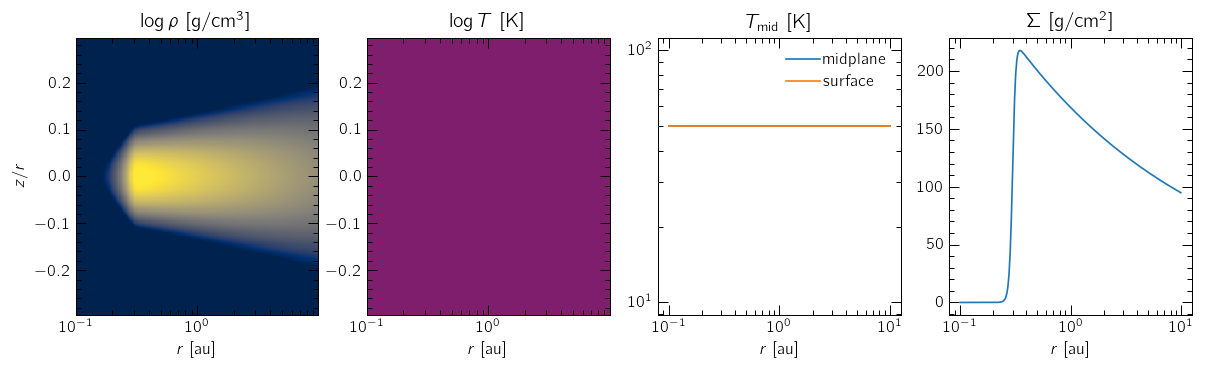

In [4]:
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[1], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [5]:
# similar to example 1, this is a very stiff problem.
# Let's first let the solver figure things out without guidance,
# and after it's started to converge to something, provide the
# previous state as an initial guess.
# This is quite problem-dependent. Of course, you can always set guess=False,
# as it's mainly a performance vs stability concern.

Disk.configure_solver(guess=False)
for _ in range(5): Disk.advance(dt=1e10 * u.yr)
Disk.configure_solver(guess=True)
for _ in range(35): Disk.advance(dt=1e10 * u.yr)

RadiativeEnvironment 'disk': Converged in 0 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iter

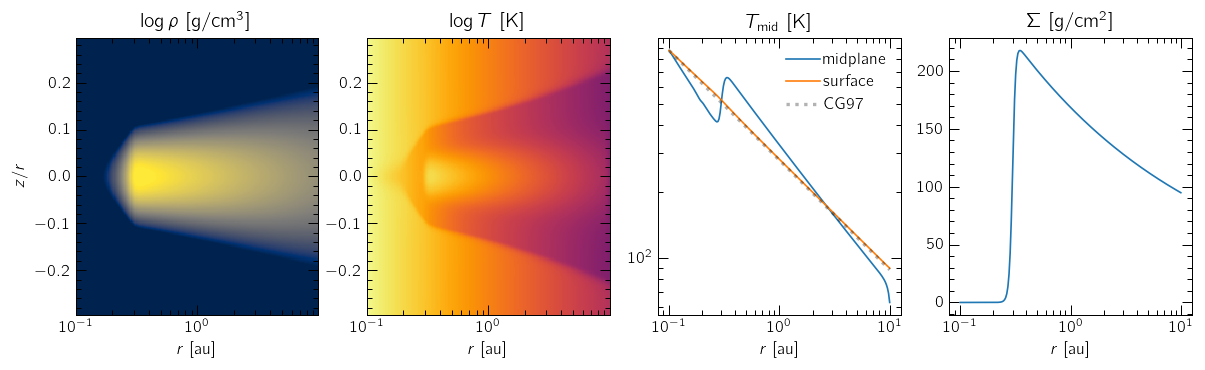

In [6]:
# ... and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane') # last index is the midplane
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[1], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# Chiang Goldreich 1997 opt. thin analytical solution
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K')
ax[2].plot(r, TCC97, ls=':', lw=2, c='k', alpha=0.3, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [7]:
# compare to an inviscid model

Disk1 = copy.deepcopy(Disk) # lazy copy of previous model
Disk1.fluids[0].viscosity = False # turn off viscosity
# continues from the previous state
for _ in range(40): Disk1.advance(dt=1e10 * u.yr) # evolve

RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iter

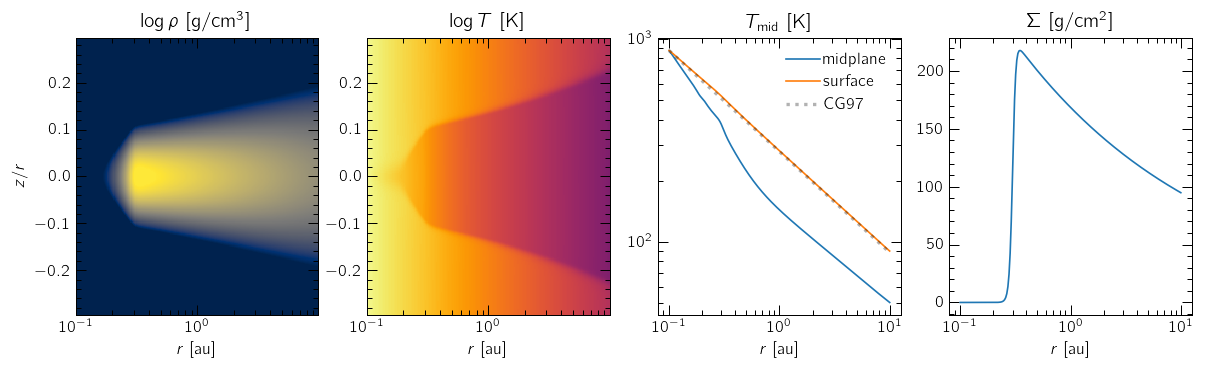

In [8]:
# ... and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk1.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk1.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk1.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk1.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk1.tmp).to_value('K')[mid], label='midplane') # last index is the midplane
ax[2].plot(r, fmt(Disk1.tmp).to_value('K')[1], label='surface') # surface
ax[3].plot(r, (fmt(Disk1.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# Chiang Goldreich 1997 opt. thin analytical solution
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K')
ax[2].plot(r, TCC97, ls=':', lw=2, c='k', alpha=0.3, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [9]:
# and a _very_ viscous model

Disk2 = copy.deepcopy(Disk) # lazy copy of previous model
Disk2.fluids[0].enroll_alpha(lambda f: 1e-3)
for _ in range(40): Disk2.advance(dt=1e10 * u.yr) # evolve

RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iter

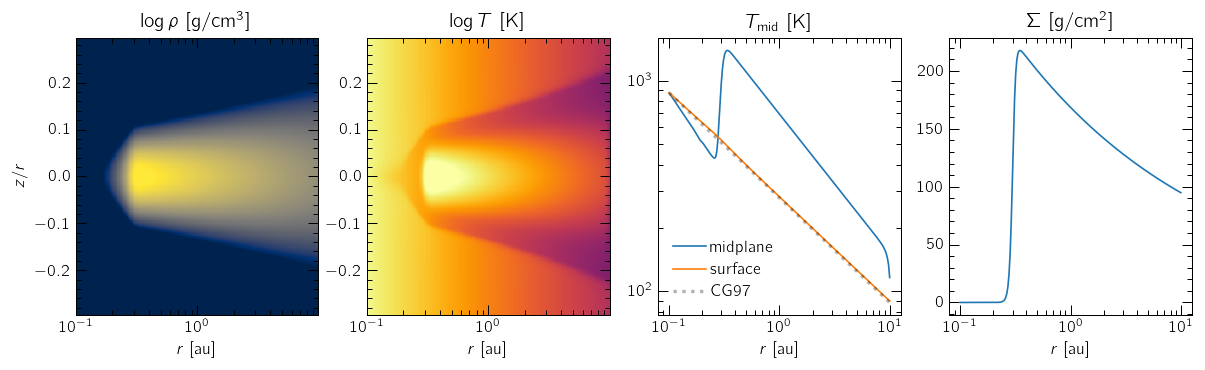

In [10]:
# ... and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk2.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk2.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk2.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk2.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk2.tmp).to_value('K')[mid], label='midplane') # last index is the midplane
ax[2].plot(r, fmt(Disk2.tmp).to_value('K')[1], label='surface') # surface
ax[3].plot(r, (fmt(Disk2.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# Chiang Goldreich 1997 opt. thin analytical solution
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K')
ax[2].plot(r, TCC97, ls=':', lw=2, c='k', alpha=0.3, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

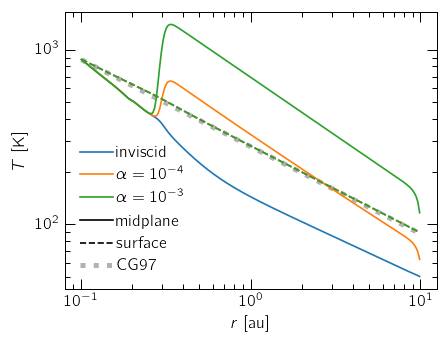

In [11]:
# let's compare the three solutions

fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
ax.plot(r, fmt(Disk1.tmp).to_value('K')[mid], c='C0', ls='-', label='inviscid')
ax.plot(r, fmt(Disk1.tmp).to_value('K')[1], c='C0', ls='--')
ax.plot(r, fmt(Disk.tmp).to_value('K')[mid], c='C1', ls='-', label=r'$\alpha=10^{-4}$')
ax.plot(r, fmt(Disk.tmp).to_value('K')[1], c='C1', ls='--')
ax.plot(r, fmt(Disk2.tmp).to_value('K')[mid], c='C2', ls='-', label=r'$\alpha=10^{-3}$')
ax.plot(r, fmt(Disk2.tmp).to_value('K')[1], c='C2', ls='--')

ax.plot(np.nan, np.nan, c='k', ls='-', label='midplane')
ax.plot(np.nan, np.nan, c='k', ls='--', label='surface')

ax.loglog()
# ax.plot(r, 140 * r ** -0.45, ls='--', c='k', alpha=0.3) # midplane fit (eyeballed)
# ax.plot(r, 350 * r ** -0.65, ls='--', c='k', alpha=0.3) # viscous midplane fit (also eyeballed)

TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K')
ax.plot(r, TCC97, ls=':', c='k', lw=3, alpha=0.3, zorder=0, label='CG97')

ax.legend()

ax.set_xlabel(r'$r$ [au]')
ax.set_ylabel(r'$T$ [K]')

plt.show()

In [12]:
# for fun, make alpha a function of temperature

Disk3 = copy.deepcopy(Disk) # lazy copy of previous model
Disk3.fluids[0].enroll_alpha(fld.tools.get_alpha_Cecil_Flock_2024)
for _ in range(40): Disk3.advance(dt=1e10 * u.yr) # evolve

RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 7 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iter

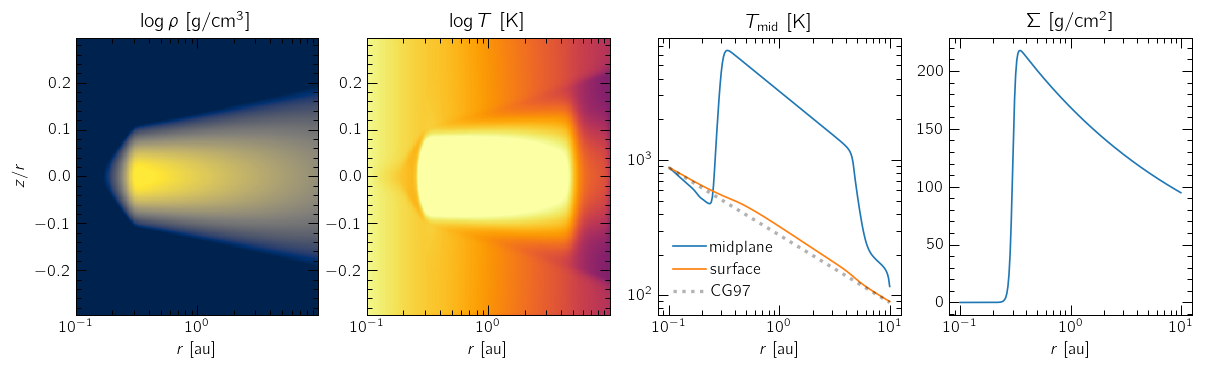

In [13]:
# ... and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk3.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk3.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk3.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk3.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk3.tmp).to_value('K')[mid], label='midplane') # last index is the midplane
ax[2].plot(r, fmt(Disk3.tmp).to_value('K')[1], label='surface') # surface
ax[3].plot(r, (fmt(Disk3.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# Chiang Goldreich 1997 opt. thin analytical solution
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K')
ax[2].plot(r, TCC97, ls=':', lw=2, c='k', alpha=0.3, label='CG97')
# ax[2].plot(r, 340 * r ** -0.65, ls='--', c='k', alpha=0.3) # viscous midplane fit (also eyeballed)

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()